/tmp/ipykernel_367/98500188.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='campaign_month', y='Total_Revenue', data=monthly_stats, palette='magma')


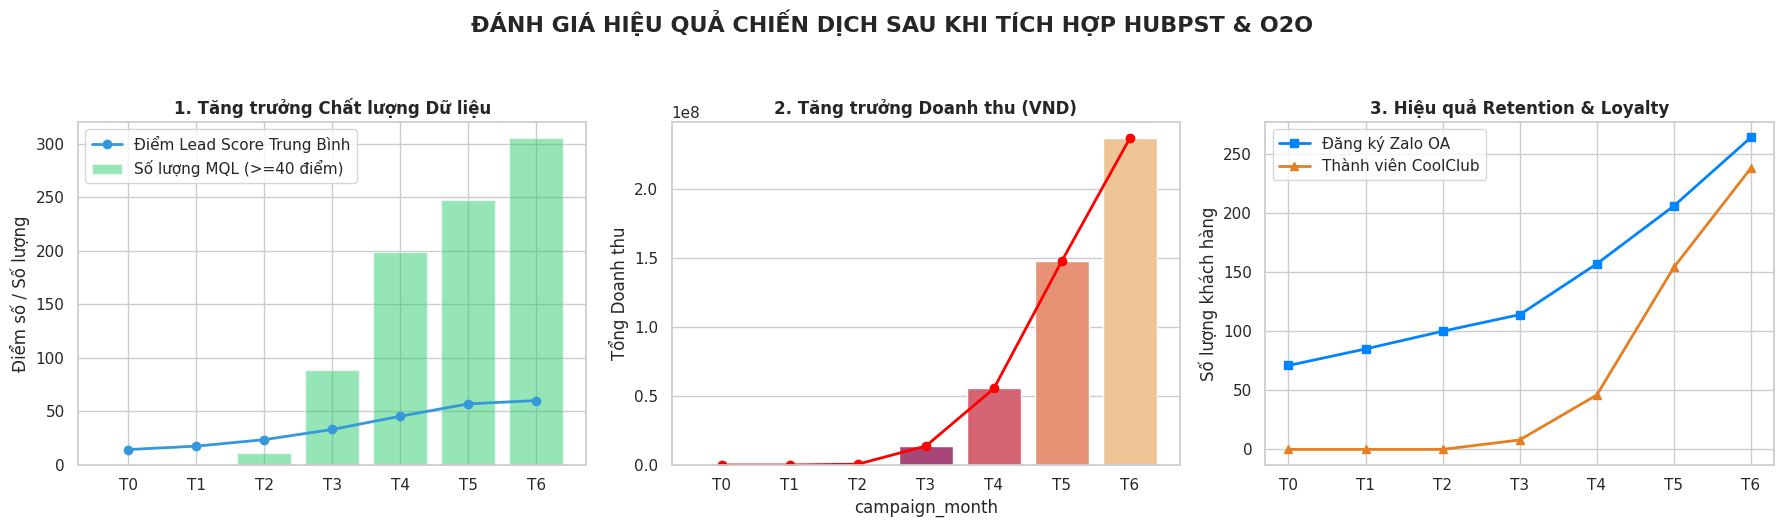

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


BẢNG SỐ LIỆU TỔNG HỢP T0 - T6 (Dành cho báo cáo):
campaign_month  MQL_Count  Avg_Lead_Score  Zalo_Subs  CoolClub_Members  Total_Revenue
            T0        0.0       14.406250         71                 0              0
            T1        0.0       17.560440         85                 0              0
            T2       11.0       23.619048        100                 0         591399
            T3       89.0       33.139344        114                 8       13744959
            T4      199.0       45.482270        157                46       55449540
            T5      247.0       57.024691        206               154      147963340
            T6      305.0       60.126943        264               238      236860054


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files # Thêm thư viện để tải file về máy

# ---------------------------------------------------------
# 1. ĐỌC VÀ GỘP DỮ LIỆU TỪ 7 FILE CSV
# ---------------------------------------------------------
file_t0 = 'coolmate_contacts_T0_before.xlsx'
files_t1_t6 = {
    'T1': 'coolmate_contacts_T1.csv',
    'T2': 'coolmate_contacts_T2.csv',
    'T3': 'coolmate_contacts_T3.csv',
    'T4': 'coolmate_contacts_T4.csv',
    'T5': 'coolmate_contacts_T5.csv',
    'T6': 'coolmate_contacts_T6.csv'
}

# Đọc file T0
df_t0 = pd.read_excel(file_t0)
df_t0.rename(columns={
    'lead_score_t0': 'lead_score',
    'lifecycle_stage_t0': 'lifecycle_stage',
    'total_revenue_t0': 'total_revenue',
    'zalo_subscribed_t0': 'zalo_subscribed',
    'coolclub_member_t0': 'coolclub_member'
}, inplace=True)
df_t0['campaign_month'] = 'T0'

# Đọc T1-T6 và gộp
df_list = [df_t0]
for month, file_name in files_t1_t6.items():
    try:
        df_temp = pd.read_csv(file_name)
        df_temp['campaign_month'] = month
        df_list.append(df_temp)
    except FileNotFoundError:
        print(f"Chưa tìm thấy file {file_name}, bác check lại xem đã upload chưa nhé!")

df_all = pd.concat(df_list, ignore_index=True)

# ---------------------------------------------------------
# 2. XỬ LÝ DỮ LIỆU
# ---------------------------------------------------------
MQL_THRESHOLD = 40

monthly_stats = df_all.groupby('campaign_month').agg(
    Total_Contacts=('contact_id', 'count'),
    Avg_Lead_Score=('lead_score', 'mean'),
    Total_Revenue=('total_revenue', 'sum'),
    Zalo_Subs=('zalo_subscribed', lambda x: (x == 'Yes').sum()),
    CoolClub_Members=('coolclub_member', lambda x: (x == 'Yes').sum())
).reset_index()

mql_counts = df_all[df_all['lead_score'] >= MQL_THRESHOLD].groupby('campaign_month').size().reset_index(name='MQL_Count')
monthly_stats = pd.merge(monthly_stats, mql_counts, on='campaign_month', how='left').fillna(0)

month_order = ['T0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6']
monthly_stats['campaign_month'] = pd.Categorical(monthly_stats['campaign_month'], categories=month_order, ordered=True)
monthly_stats = monthly_stats.sort_values('campaign_month')

# ---------------------------------------------------------
# 3. VẼ BIỂU ĐỒ & XUẤT FILE ẢNH
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ĐÁNH GIÁ HIỆU QUẢ CHIẾN DỊCH SAU KHI TÍCH HỢP HUBPST & O2O', fontsize=16, fontweight='bold', y=1.05)

# Biểu đồ 1
axes[0].plot(monthly_stats['campaign_month'], monthly_stats['Avg_Lead_Score'], marker='o', label='Điểm Lead Score Trung Bình', color='#3498DB', linewidth=2)
axes[0].bar(monthly_stats['campaign_month'], monthly_stats['MQL_Count'], alpha=0.5, label='Số lượng MQL (>=40 điểm)', color='#2ECC71')
axes[0].set_title('1. Tăng trưởng Chất lượng Dữ liệu', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Điểm số / Số lượng')
axes[0].legend()

# Biểu đồ 2
sns.barplot(ax=axes[1], x='campaign_month', y='Total_Revenue', data=monthly_stats, palette='magma')
axes[1].plot(monthly_stats['campaign_month'], monthly_stats['Total_Revenue'], color='red', marker='o', linewidth=2)
axes[1].set_title('2. Tăng trưởng Doanh thu (VND)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tổng Doanh thu')
axes[1].tick_params(axis='x', rotation=0)

# Biểu đồ 3
axes[2].plot(monthly_stats['campaign_month'], monthly_stats['Zalo_Subs'], marker='s', label='Đăng ký Zalo OA', color='#0084FF', linewidth=2)
axes[2].plot(monthly_stats['campaign_month'], monthly_stats['CoolClub_Members'], marker='^', label='Thành viên CoolClub', color='#E67E22', linewidth=2)
axes[2].set_title('3. Hiệu quả Retention & Loyalty', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Số lượng khách hàng')
axes[2].legend()

plt.tight_layout()

# Lệnh lưu hình ảnh độ phân giải cao
file_name = "Coolmate_Campaign_Dashboard.png"
plt.savefig(file_name, dpi=300, bbox_inches='tight')

# Hiển thị biểu đồ trên màn hình Colab
plt.show()

# Lệnh tự động kích hoạt cửa sổ tải file về máy
files.download(file_name)

print("\nBẢNG SỐ LIỆU TỔNG HỢP T0 - T6 (Dành cho báo cáo):")
print(monthly_stats[['campaign_month', 'MQL_Count', 'Avg_Lead_Score', 'Zalo_Subs', 'CoolClub_Members', 'Total_Revenue']].to_string(index=False))